# Laboratory 8: Text-to-Image Generation with Latent Diffusion

This laboratory covers:

* Conducting forward and reverse diffusion processes in the lower-dimensional space
* Compressing an image into a lower-dimensional space
* Converting low-resolution images into high-resolution ones
* Generating high-resolution images based on text prompts using a latent diffusion model
* Modifying existing images based on text prompts

We have explored diffusion models in depth in Laboratories 4 to 6. In particular, we have learned how to build and train a model to generate clothing-item images conditioned on labeling information in Laboratory 5. Text-to-image diffusion models can be viewed as a type of conditional generation as well: the goal is to create images conditional on text prompts. We first train a diffusion model to remove noise from images using the text prompt as a guide. To generate an image, we start with an image composed of pure random noise and iteratively refine it using the trained U-Net denoising model. This requires the diffusion model to effectively incorporate the text description as the conditioning information and generate a coherent image that matches this description.

However, generating images with diffusion models conditional on text prompts comes with a high computational cost: high-resolution images have too many pixels. For example, a three-channel color image with a width and height of $512$ has a total of $3\times 512 \times 512=786,432$ pixels. Further, diffusion models require noise to be added and removed from images over many iterations (often $1000$ or more), which further increases the computational needs and makes both training and inference inefficient and slow.

To overcome the challenge, Rombach et al. published a paper in 2022 to propose a *latent diffusion model* (*LDM*).  Instead of conducting forward and reverse diffusion processes on high-resolution images, the authors propose conducting the diffusion processes in a lower-dimensional space (i.e., the latent space). Since images in the latent space are much smaller in size, the diffusion processes are much faster. However, this means lower quality of the generated images. To compensate for this, after the LDM is trained, we use a variational autoencoder (VAE) to convert the low-resolution latent images back into high-resolution ones as the final output. A VAE is a generative model composed of an encoder and a decoder. The encoder transforms high-resolution images into compact, lower-dimensional representations, which the decoder then uses to reconstruct the original image. The decoder's ability to convert low-resolution images into high-resolution output is an essential part of the LDM.

In this laboratory, we will learn how LDMs work. Instead of conducting forward and reverse diffusion processes on high-resolution images of size $(3, 512, 512)$, the LDM in this laboratory conducts diffusion processes in a latent space where images have dimensions of $(4, 64, 64)$. This reduces the size of the input to the diffusion model by $48$ times since $(3\times 512\times 512)/(4\times 64\times 64)=48$. This greatly speeds up the diffusion processes. Once the diffusion model is trained, a text prompt is fed to the model to generate images with a size of $(4, 64, 64)$. These low-resolution images are then fed to a trained VAE, which converts them into high-resolution images of size $(3, 512, 512)$.

LDMs are also excellent image editors. We can use a trained LDM to modify an existing image based on a text prompt. Suppose we have an image of a white horse with snow in the background. If we use the prompt "a white horse walks on a sunny sandy beach" to edit the image, the result will show a similar horse, but the background is now a sunny and sandy beach. When we use the prompt "a zebra walks on a white, snow-covered ground" to modify the image, the snowy background will stay almost the same but the horse will become a zebra (as if we magically put black stripes on the white horse).

# 1. Compressing and reconstructing images with VAEs
To understand how VAEs compress and then reconstruct images, we will first download a pre-trained VAE that we will use in our LDM. We will then use the encoder in the VAE to compress two example high-resolution images to the latent space. After that, we will use the decoder in the VAE to reconstruct the images. We will compare the reconstructed images with the original ones and see if any information is lost in the process.

## 1.1. Download the pre-trained VAE
First, download the two files `vocab.json` and `merges.txt` from Hugging Face https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/tree/main/tokenizer
and save them in the `files` folder. Then go to another Hugging Face site https://huggingface.co/ogkalu/Illustration-Diffusion/tree/main and download the file `hollie-mengert.ckpt` and save it in the `files` folder. Alternatively, we can run the following code cell to download the three files:

In [ ]:
import requests, os

# urls for the files
urls=("https://huggingface.co/ogkalu/Illustration-Diffusion"
    "/resolve/main/hollie-mengert.ckpt?download=true",
    "https://huggingface.co/stable-diffusion-v1-5/"
    "stable-diffusion-v1-5/resolve/main/tokenizer/merges.txt",
    "https://huggingface.co/stable-diffusion-v1-5/"
    "stable-diffusion-v1-5/resolve/main/tokenizer/vocab.json")

files=["files/hollie-mengert.ckpt",
       "files/merges.txt",
       "files/vocab.json"] #Where to save the three files

if all(os.path.exists(file) for file in files): #Checks if the three files already exist
    print("files have already been downloaded")
else: #If not, downloads the three files
    print("downloading files")
    for url, file in zip(urls, files):
        fb=requests.get(url)
        with open(file,"wb") as f:
            f.write(fb.content)
    print("download complete")

downloading files
download complete


The links to download the three files are provided in the tuple `urls`. We check to see if the
three files already exist. If not, use the `requests` library to download
the files and save them.

Run the following code cell to clone the Stable Diffusion GitHub repository:

In [ ]:
!git clone https://github.com/hkproj/pytorch-stable-diffusion

Cloning into 'pytorch-stable-diffusion'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 73 (delta 24), reused 15 (delta 15), pack-reused 34 (from 1)
Receiving objects: 100% (73/73), 1.97 MiB | 25.25 MiB/s, done.
Resolving deltas: 100% (30/30), done.


We will find a folder `pytorch-stable-diffusion` containing all files in the
GitHub repository. Next, we load the pretrained VAE.

In [ ]:
# access the directory /pytorch-stable-diffusion/sd/
import sys
sys.path.append("pytorch-stable-diffusion/sd")    #Accesses the subdirectory in the cloned GitHub repository

from model_converter import load_from_standard_weights
from encoder import VAE_Encoder
from decoder import VAE_Decoder
import torch

model_file = "files/hollie-mengert.ckpt"
state_dict = load_from_standard_weights(model_file,
        "cpu")    #Loads the pretrained weights in the VAE
encoder = VAE_Encoder()
encoder.load_state_dict(state_dict['encoder'],
        strict=True)    #Creates the VAE encoder
decoder = VAE_Decoder()
decoder.load_state_dict(state_dict['decoder'],
        strict=True)    #Creates the VAE decoder

<All keys matched successfully>

The `sys.path.append()` method allows us to access a subdirectory on the computer.
We use the method here to access the module `files` in the cloned GitHub repository. We
then instantiate a VAE and load the pretrained weights to the encoder and decoder.

Download the two image files [`beaver.jpg`](https://drive.google.com/file/d/1hPg0gcG_9t-yZlvpsP9-CMOdLUhPsUFr/view?usp=drive_link) and [`dolphin.png`](https://drive.google.com/file/d/1yVQ-iilYeUpnVwvJg8JkatXrXbvg9lYO/view?usp=drive_link) and place them in the `files` folder. We will load the two images and use the pre-trained VAE encoder to compress them to the latent space:

In [ ]:
from PIL import Image
from torchvision import transforms

def center_crop(img):    #Defines a function to center crop an image
    width, height = img.size
    new=min(width,height)
    left = (width - new)/2
    top = (height - new)/2
    right = (width + new)/2
    bottom = (height + new)/2
    im = img.crop((left, top, right, bottom))
    return im
image1=center_crop(Image.open(
    "files/beaver.jpg")).resize((128,128))    #Loads the beaver image and resizes it to 3 × 512 × 512
image2=center_crop(Image.open(
    "files/dolphin.png")).resize((128,128))    #Loads the dolphin image and resizes it to 3 × 512 × 512
transform=transforms.ToTensor()
image1=transform(image1)
image2=transform(image2)
print(image1.shape, image2.shape)    #Prints out the shapes of the resized images

torch.Size([3, 128, 128]) torch.Size([3, 128, 128])


We define a `center_crop()` function to crop the center square of an image. Doing so
will ensure that the image has the same width and height; otherwise, the resized image
may appear distorted and disproportional. We then load the beaver and dolphin
images, center crop them, and resize them to a shape of $3 \times 512 \times 512$.

The output shows that both images are PyTorch tensors with a size of $3 \times 512 \times 512$.
Next, we will use the VAE encoder to compress them into representations in the lower-dimensional
latent space.

## 1.2. Encoding and decoding images with the pretrained VAE
Both images have a size of $(3, 512, 512)$, meaning three color channels, with width and height of $512$ pixels. The VAE encoder will compress images of size $3 \times 512 \times 512$ to a lower dimension of
$4 \times 64 \times 64$. Doing so greatly reduces the pixel count of the images. We can compress
the two example images we just prepared into the latent space with the pretrained VAE
encoder:

In [ ]:
N=torch.distributions.Normal(0, 1)
noise=N.sample(torch.Size([1,4,16,16]))    #Sample from the standard normal distribution
latent1=encoder(image1.unsqueeze(0),
    noise)[0]
latent2=encoder(image2.unsqueeze(0),
    noise)[0]    #Compresses the beaver and dolphin images to the latent space
print(latent1.shape,latent2.shape)    #Prints out the shape of the compressed images

torch.Size([4, 16, 16]) torch.Size([4, 16, 16])


We first sample a noise tensor from the standard normal distribution. We then use the
pretrained VAE encoder to sample latent representations for the two images in the
lower-dimensional space. We call them `latent1` and `latent2`, respectively. The output indicates that the two images are now compressed to a size of $4 \times 64 \times 64$.

Now, let's visually compare the original images with the images in the latent space:

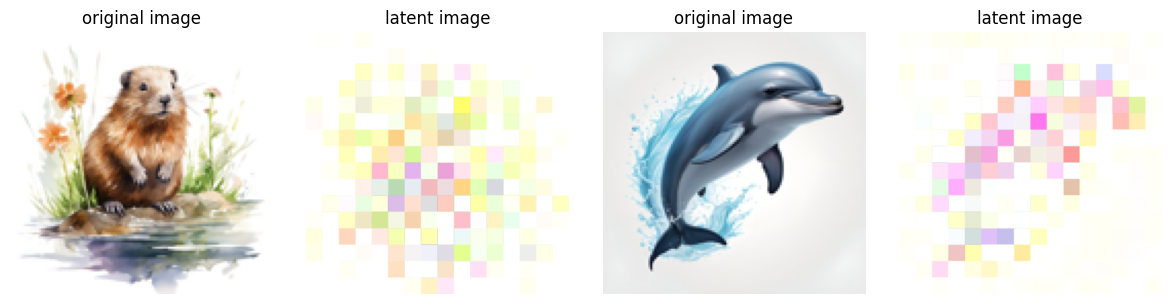

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

imgs=[image1.permute(1,2,0),
  torch.clip(latent1.permute(1,2,0),-1,1).detach().cpu().numpy(
      ).repeat(8, axis=0).repeat(8,axis=1)/2+0.5,
      image2.permute(1,2,0),\
  torch.clip(latent2.permute(1,2,0),-1,1).detach().cpu().numpy(
  ).repeat(8, axis=0).repeat(8,axis=1)/2+0.5]    #Places the original images and compressed images in one list
plt.figure(figsize=(12,3),dpi=100)
for i in range(4):    #Plots the four images in a 1 × 4 grid
    plt.subplot(1,4, i+1)
    plt.imshow(imgs[i])
    if i%2==0:
        plt.title("original image")
    else:
        plt.title("latent image")    #Labels each image as either original or latent
    plt.axis('off')
plt.tight_layout()
plt.show()

We place the two original images and the two compressed images in the same list `imgs`.
We then plot the four images in a $1 \times 4$ grid. We label each image as either “original
image” or “latent image”. The result is shown above.

The original
images have $48$ times more pixels than the latent images have. However, we can still tell
that the second image is a beaver and the last image is a dolphin, indicating that the
VAE encoder has captured the essential features of the two images.

Next, we feed the two latent images, `latent1` and `latent2`, to the pretrained VAE
decoder to convert them back to the original high-dimensional space:

In [ ]:
reconstruct1=decoder(latent1.unsqueeze(0))
reconstruct2=decoder(latent2.unsqueeze(0))
print(reconstruct1.shape,reconstruct2.shape)

torch.Size([1, 3, 128, 128]) torch.Size([1, 3, 128, 128])


The two decoded images are saved as `reconstruct1` and `reconstruct2`, respectively. We
printed out the shapes of the two reconstructed images. The output shows that the two latent images are converted to the original high-dimensional
space, with shapes of $3 \times 512 \times 512$. We plot both the original images and
the reconstructed images to compare them.

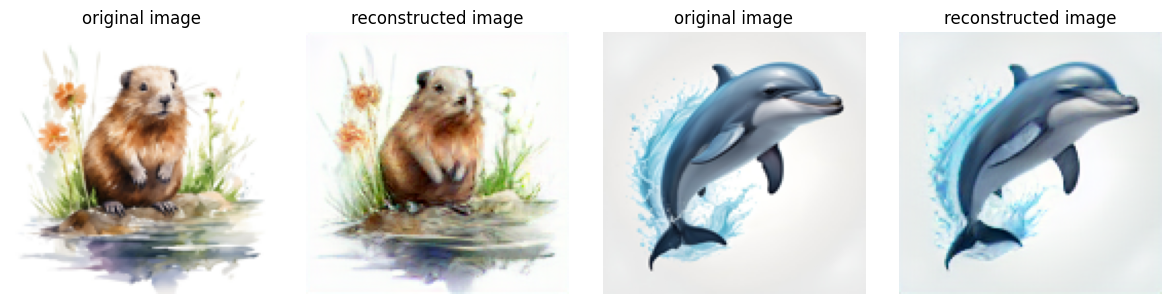

In [ ]:
imgs=[image1.permute(1,2,0),
  torch.clip(reconstruct1[0].permute(1,2,0),
    0,1).detach().cpu().numpy(),
    image2.permute(1,2,0),
  torch.clip(reconstruct2[0].permute(1,2,0),
             0,1).detach().cpu().numpy()]    #Places original and reconstructed images in a list
plt.figure(figsize=(12,3),dpi=100)
for i in range(4):    #Plots the four images in a 1 × 4 grid
    plt.subplot(1,4, i+1)
    plt.imshow(imgs[i])
    if i%2==0:
        plt.title("original image")
    else:
        plt.title("reconstructed image")    #Labels each image as either original or reconstructed
    plt.axis('off')
plt.tight_layout()
plt.show()

We first place the two original and the two reconstructed images in a list. We then plot
them in a $1 \times 4$ grid and label each image as either original or reconstructed. The output is shown above.

The first and third images are the original images, while the second and
fourth images are the reconstructed ones. The reconstructed images closely resemble
the original ones, which indicates that the VAE decoder can successfully reconstruct an
image.

# 2. Text-to-image generation with latent diffusion
## 2.1. Guidance by the CLIP model


We will use a pretrained CLIP model to guide the diffusion model to generate latent
images that match the descriptions in the text prompt. We will first use the pretrained
CLIP tokenizer from the `transformers` library to tokenize the text prompt (make sure
you have the two files `vocab.json` and `merges.txt` saved):

In [ ]:
!pip install transformers==4.55.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 101.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from transformers import CLIPTokenizer
from clip import CLIP

device="cuda" if torch.cuda.is_available() else "cpu"
decoder.to(device)
tokenizer = CLIPTokenizer(vocab_file="files/vocab.json",
    merges_file="files/merges.txt", use_fast=False)    #Instantiates the CLIPTokenizer() class
clip = CLIP().to(device)    #Creates a CLIP model
clip.load_state_dict(state_dict['clip'],
    strict=True)    #Loads pretrained weights to the CLIP model

<All keys matched successfully>

The `CLIPTokenizer` class is used to tokenize text, and the vocabulary (i.e., collection
of tokens) comes from the two files we just downloaded. We also import the CLIP
model from the GitHub repository directly and load it with the pretrained
weights. From now on, we will move different parts of the model (e.g., the VAE decoder,
the CLIP tokenizer, and later the diffusion model) and all tensors to the GPU if our
computer has a CUDA-enabled GPU. We do this to speed up the image-generation
process.

We will use “a banana riding a motorcycle, wearing sunglasses and a straw hat, highly
detailed, ultra sharp, cinematic, 100 mm lens, 8k resolution” as our prompt. Because
the final output is a combination of conditional and unconditional generation, as we
explained in Laboratory 5, we need an unconditional prompt as well. An unconditional
prompt is essentially an empty string passed to the text encoder. It represents the
absence of any specific condition or descriptive information.

We will use the classifier-free guidance (CFG) parameter, `cfg_scale`, to steer the generation
process toward outputs that better match the provided conditional prompt, while
reducing artifacts. We do this by combining the predictions obtained from both the
conditional prompt and the unconditional prompt, as shown in the code below. This mechanism
pushes the generation closer to what the conditional prompt describes while
using the unconditional output as a baseline to maintain diversity and stability in the
output.

In [ ]:
prompt = '''A banana riding a motorcycle, wearing sunglasses and
a straw hat, highly detailed, ultra sharp, cinematic,
100mm lens, 8k resolution.'''

uncond_prompt=""

seed=42
with torch.no_grad():
    generator=torch.Generator(device=device)
    generator.manual_seed(seed)
    cond_tokens=tokenizer.batch_encode_plus(
    [prompt], padding="max_length", max_length=77).input_ids
    print(cond_tokens)
    cond_tokens=torch.tensor(cond_tokens,
        dtype=torch.long,device=device)    #Tokenizes the conditional prompt into a 77-token tensor
    print("conditional tokens are\n", cond_tokens)
    cond_context = clip(cond_tokens).to(device)    #Uses the CLIP text encoder to encode the conditional prompt
    uncond_tokens=tokenizer.batch_encode_plus(
        [uncond_prompt], padding="max_length",
        max_length=77).input_ids
    uncond_tokens=torch.tensor(uncond_tokens,
       dtype=torch.long,device=device)
    print("unconditional tokens are\n", uncond_tokens)
    uncond_context = clip(uncond_tokens).to(device)    #Does the same for the unconditional prompt
    clip.to("cpu")
    context=torch.cat([cond_context,uncond_context])    #Concatenates encoded conditional and unconditional prompts

[[49406, 320, 8922, 6765, 320, 10297, 267, 3309, 12906, 537, 320, 16438, 3801, 267, 5302, 12609, 267, 8118, 8157, 267, 25602, 267, 272, 271, 271, 2848, 8666, 267, 279, 330, 9977, 269, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407]]
conditional tokens are
 tensor([[49406,   320,  8922,  6765,   320, 10297,   267,  3309, 12906,   537,
           320, 16438,  3801,   267,  5302, 12609,   267,  8118,  8157,   267,
         25602,   267,   272,   271,   271,  2848,  8666,   267,   279,   330,
          9977,   269, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
  

The second half of the prompt, “highly detailed, ultra sharp, cinematic, 100 mm lens,
8k resolution,” provides the image generator with more specific instructions about
the style, quality, and technical aspects of the image. This helps the model focus on
producing a more refined and polished image. We fix the random state at $42$ so that
results are reproducible. We convert both conditional and unconditional prompts
into $77$-element
tensors. The CLIP text encoder is designed to accept inputs of a fixed
length ($77$ tokens). This design decision was made to provide enough context for a
wide range of inputs while keeping the computational requirements manageable. If
a prompt is shorter than $77$ tokens, it gets padded; if longer, it is truncated. This standardization
ensures that every input, whether conditional or unconditional, fits the
same $77$-token structure.

We then use the CLIP text encoder to convert the tokenized conditional prompt into
a text embedding. We do the same for the tokenized unconditional prompt. Finally, we
combine the two embeddings in the same tensor named `context`.

As we can see from the preceding output, we use the integer $49406$ to signal the start of
the sequence, and we use the integer $49407$ to pad the sequence so it has $77$ elements.

## 2.2.	Diffusion in the latent space

To conduct diffusion in the latent space, we need to first initiate a diffusion model and
create a noise scheduler. The following code accomplishes those tasks.

In [ ]:
from diffusion import Diffusion
import torch
from ddpm import DDPMSampler

diffusion = Diffusion().to(device)
diffusion.load_state_dict(state_dict['diffusion'],
    strict=True)    #Initiates the diffusion model from the GitHub repository and loads pretrained weights
def get_time_embedding(timestep):    #Creates time embedding
    freqs = torch.pow(10000, -torch.arange(start=0,
                   end=160, dtype=torch.float32) / 160)
    x = torch.tensor([timestep],
         dtype=torch.float32)[:, None] * freqs[None]
    return torch.cat([torch.cos(x), torch.sin(x)], dim=-1)
num_reference_steps=50
sampler=DDPMSampler(generator)
sampler.set_inference_timesteps(num_reference_steps)    #Creates a noise scheduler and sets the number of inference time steps to 50

We initiate the diffusion model from the GitHub repository. We then load
the pretrained weights into the model. We also create fixed time embedding using
sine and cosine functions, as we did in Laboratory 1 for positional encoding. The time
embedding is needed in the denoising process so that the model knows which time
step a noisy image is in, as we explained in Laboratory 5. Finally, we create a noise scheduler
from the GitHub repository and set the number of inference time
steps to $50$. Next, we generate an image in the latent space using the pretrained diffusion
model.

In [ ]:
from tqdm import tqdm
from copy import deepcopy

cfg_scale=8
latent_shape=(1,4,16,16)
noisy_latents=[]
with torch.no_grad():
    latents=torch.randn(latent_shape,
        generator=generator,device=device)    #Start with an image consisting of pure noise.
    timesteps=tqdm(sampler.timesteps)
    for i, timestep in enumerate(timesteps):    #Iteratively denoise for 50 inference steps.
        time_embedding=get_time_embedding(timestep).to(device)
        model_input=latents.to(device)
        model_input=model_input.repeat(2,1,1,1)
        model_output=diffusion(model_input,context,time_embedding)
        output_cond,output_uncond=model_output.chunk(2)
        model_output=cfg_scale*(output_cond-output_uncond)+\
            output_uncond    #The model output is a combination of conditional and unconditional generation.
        latents=sampler.step(timestep,latents,model_output)
        if i%10==9:
            noisy_latents.append(deepcopy(latents))    #Save the intermediate images to the list noisy_latents.
diffusion.to("cpu")

100%|██████████| 50/50 [00:04<00:00, 11.05it/s]


Diffusion(
  (time_embedding): TimeEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (unet): UNET(
    (encoders): ModuleList(
      (0): SwitchSequential(
        (0): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (1-2): 2 x SwitchSequential(
        (0): UNET_ResidualBlock(
          (groupnorm_feature): GroupNorm(32, 320, eps=1e-05, affine=True)
          (conv_feature): Conv2d(320, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (linear_time): Linear(in_features=1280, out_features=320, bias=True)
          (groupnorm_merged): GroupNorm(32, 320, eps=1e-05, affine=True)
          (conv_merged): Conv2d(320, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (residual_layer): Identity()
        )
        (1): UNET_AttentionBlock(
          (groupnorm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (conv_inp

We set the CFG guidance parameter to $8$ for the moment. We will explore how different
values of this parameter affect the output later. The shape of the latent image is $(1, 4,
64, 64)$, meaning $1$ image in the batch, and the image has a shape of $4 \times 64 \times 64$. We
start with an image consisting of pure noise (corresponding to $t = 1,000$) and iteratively
remove noise from the image, guided by the text prompt. Note that the `diffusion`
function in the code above takes three arguments, which guide the diffusion model to
predict the noise in the image so we can remove noise effectively:

*   `model_input`—The noisy image.
*   `context`—Encodes both the conditional and unconditional text prompts.
*   `time_embedding`—Embeds the time step so the model knows which time step the
noisy image is in.

Because we use $50$ inference time steps, we generate $50$ images corresponding to time
steps $t = 980, 960, . . ., 20$, and $0$. We saved $5$ noisy images at time steps $t = 800, 600, 400,
200$, and $0$, respectively, for later use.

## 2.3. Converting latent images to high-resolution ones

The images generated in the latent space have a shape of $4 \times 64 \times 64$. We wil use the pretrained
VAE to convert them into high-resolution images with a shape of $3 \times 512 \times 512$
in the high-dimensional space. We first convert the final, clean image at time step $0$ in
the latent space into a high-resolution image:

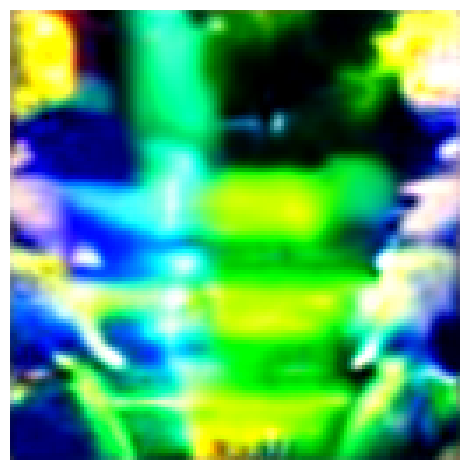

In [ ]:
final_latent=noisy_latents[-1]    #Retrieves the final latent image
final_output=decoder(final_latent)    #Uses the pretrained VAE decoder to convert the latent image to a high-resolution image
img=torch.clip(final_output[0].permute(1,2,0)/2+0.5,0,1)    #Changes the image to the channel-last format
plt.figure(dpi=100)
plt.imshow(img.detach().cpu().numpy())    #Displays the final output
plt.axis("off")
plt.tight_layout()
plt.show()

We retrieve the final latent image from the list `noisy_latents` that we generated in the
previous subsection. We then use the pretrained VAE decoder to convert the latent
image into a high-resolution image. The output is shown above.

As we can see, the image shows a human-shaped banana riding a motorcycle. The
rider wears a straw hat and sunglasses, as described in the text prompt. This shows the
ability of the trained LDM to generate images that closely match the text prompt. To
get a better understanding of how the latent diffusion processes work, we can plot the
five latent images in the list `noisy_latents`:

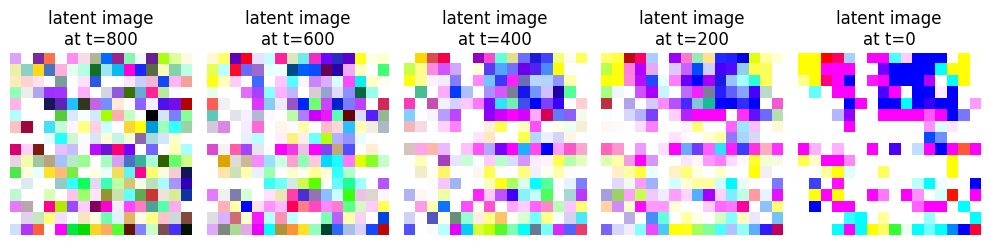

In [ ]:
plt.figure(figsize=(10,3),dpi=100)
for i in range(5):    #Plots the five images in a 1 × 5 grid
    im=torch.clip(noisy_latents[i][0].permute(1,2,0)/2+0.5,0,1)
    plt.subplot(1,5, i+1)
    plt.imshow(im.detach().cpu().numpy())
    plt.title(f"latent image\nat t={800-i*200}")    #Shows which time step the latent image is in
    plt.axis('off')
plt.tight_layout()
plt.show()

We plot the five images in a $1 \times 5$ grid. The images are shown above. The far-left image above is at time step $t = 800$. The image is indistinguishable
from random noise. The middle three images are at time steps $t = 600, 400$, and $200$,
respectively. They start to show a banana-shaped rider on a motorcycle. The far-right
image is the clean image at $t = 0$. Even though the resolution is low, the image fits the
text prompt well.

All the images in above are low-resolution images with a shape of $4 \times 64 \times 64$.
We can use the pretrained VAE decoder to convert them into high-resolution images,
which are shown as output of the code below:

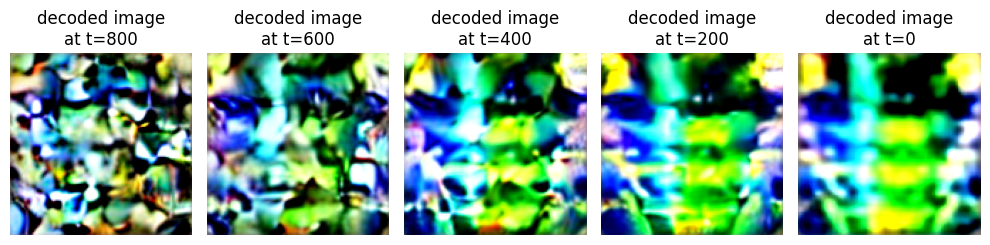

In [ ]:
plt.figure(figsize=(10,3),dpi=100)
for i in range(5):
    im=decoder(noisy_latents[i])    #Uses the VAE decoder to convert latent images to high resolution ones
    im=torch.clip(im[0].permute(1,2,0)/2+0.5,0,1)
    plt.subplot(1,5, i+1)    #Plots the decoded image
    plt.imshow(im.detach().cpu().numpy())
    plt.title(f"decoded image\nat t={800-i*200}")    #Indicates which time step the image is in
    plt.axis('off')
plt.tight_layout()
plt.show()

The five images in the latent space are now converted into high-resolution images,
with a shape of $3 \times 512 \times 512$. As we go from left to right in the figure above, the decoded image becomes clearer and clearer. The far-right image is the final output from the
LDM model that we saw earlier.

# 3.	Modifying existing images with text prompts

The LDM can also modify an existing image based on a text prompt. The process of
modifying an existing image using an LDM works very much like generating an image
from scratch, but with a key difference: we start from an encoded version of the image
rather than pure noise.

The process begins by taking our existing image and encoding it into a latent representation
using the pretrained VAE encoder. The VAE compresses the image into
a lower-dimensional
latent space
that captures its essential features.
To allow the model to modify the
image based on a text prompt,
a controlled amount of noise is
introduced to the latent representation.
The level of noise is
governed by a “strength” parameter,
which determines how much
the final image will deviate from
the original. Less noise preserves
more of the original image, while
more noise allows for greater
modifications.

Download the image [`horse.png`](https://drive.google.com/file/d/153UyY9DMbPh9qeOj58mV81rOjPtWn23_/view?usp=drive_link). It is an image of a
white horse walking on white,
snow-covered ground.

In the following, we modify the image to show a white horse walking on a
sunny, sandy beach.

In [ ]:
exit()

In [ ]:
import torch
from PIL import Image
from transformers import CLIPTokenizer
import matplotlib.pyplot as plt
import sys
sys.path.append("pytorch-stable-diffusion/sd")

device="cuda" if torch.cuda.is_available() else "cpu"
tokenizer = CLIPTokenizer(vocab_file="files/vocab.json",
    merges_file="files/merges.txt", use_fast=False)
model_file = "files/hollie-mengert.ckpt"

In [ ]:
import pipeline
import model_loader

models=model_loader.preload_models_from_standard_weights(model_file,
    device)
prompt="A white horse walks on the sunny sandy beach."    #The prompt used to modify the image
uncond_prompt=""
input_image = Image.open("files/horse.png")    #The existing image

output_image = pipeline.generate(    #Uses the generate() function in the pipeline module in the GitHub repository
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=0.8,    #Sets the strength parameter to 0.8
    do_cfg=True,
    cfg_scale=8,
    sampler_name="ddpm",
    n_inference_steps=50,
    seed=42,
    models=models,
    device=device,
    idle_device="cpu",
    tokenizer=tokenizer,)

100%|██████████| 40/40 [00:19<00:00,  2.01it/s]


We start with a white horse running in the snow. We use the prompt "A white horse walks on the sandy beach under blue sky". The end result is a new image. We still have a white horse resembling the white horse in the original image. However, the background is now a sunny sandy beach instead of a cold white snow-covered field, as we can see from the image below after plotting it with the `matplotlib` library:

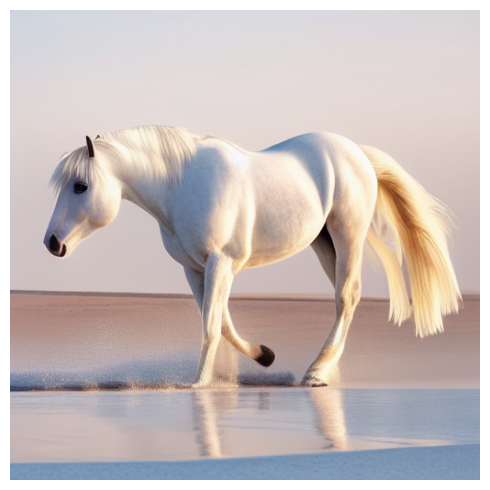

In [ ]:
plt.figure(figsize=(5,5),dpi=100)
plt.imshow(output_image)
plt.axis('off')
plt.tight_layout()
plt.show()

The `generate()` function in the `pipeline` module in the GitHub repository
can be used to modify an existing image or generate an image from scratch. The
strength argument in the function ranges from `0` to `1`, and it controls how much to
modify the image: a higher value means the output deviates more from the original
image.

Let's try another example of modifying existing images. We will start with the same image of white horse with snow background. However, we change the prompt to “A zebra walks on the white, snow-covered ground”.

100%|██████████| 25/25 [00:12<00:00,  2.03it/s]


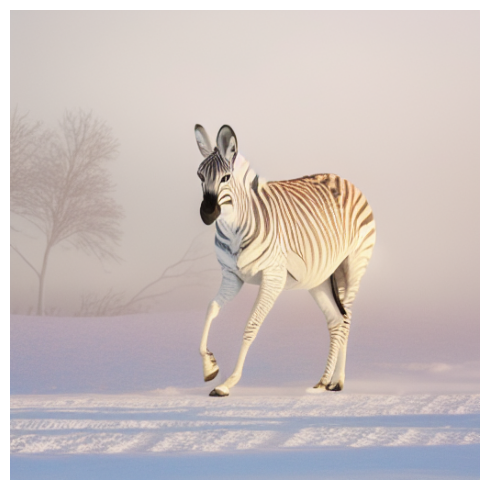

In [ ]:
prompt="A zebra walks on the white, snow-covered ground."    #The new text prompt used to modify the image
output_image = pipeline.generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=0.5,    #Sets the strength parameter to 0.5
    do_cfg=True,
    cfg_scale=8,
    sampler_name="ddpm",
    n_inference_steps=50,
    seed=42,
    models=models,
    device=device,
    idle_device="cpu",
    tokenizer=tokenizer,)
plt.figure(figsize=(5,5),dpi=100)
plt.imshow(output_image)
plt.axis('off')
plt.tight_layout()
plt.show()

We again use the `generate()` function in the `pipeline` module to modify the horse
image. This time, we set the strength argument in the function to `0.5`. The generated
image looks very similar to the original image, except that the horse now becomes a
zebra.

We have set the `cfg_scale` parameter to a value of `8` thus far when generating images. If
we set the parameter to a lower value, say, `5`, the output is more diverse but may not
align perfectly with the text prompt. On the other hand, if we set the parameter to a
higher value, say, `12`, the output is more aligned with the text prompt. However, setting
the parameter too high may lead to overfitting the prompt or a reduction in the natural
diversity of the output.

Next, we use the same text prompt, “A banana riding a motorcycle, wearing sunglasses
and a straw hat, highly detailed, ultra sharp, cinematic, 100 mm lens, 8k resolution”,
that we used before, but set the `cfg_scale` parameter to `12`.

100%|██████████| 50/50 [00:25<00:00,  1.97it/s]


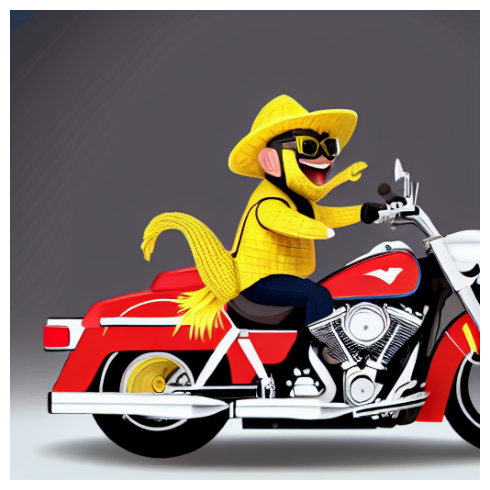

In [ ]:
prompt = '''A banana riding a motorcycle, wearing sunglasses and
a straw hat, highly detailed, ultra sharp, cinematic,
100mm lens, 8k resolution.'''
uncond_prompt=""
output_image12 = pipeline.generate(    #Uses the generate() function in the pipeline module
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=None,    #Sets the input_image argument to None
    strength=1,
    do_cfg=True,
    cfg_scale=12,    #Sets the cfg_scale argument to 12
    sampler_name="ddpm",
    n_inference_steps=50,
    seed=42,
    models=models,
    device=device,
    idle_device="cpu",
    tokenizer=tokenizer,)
plt.figure(figsize=(5,5),dpi=100)
plt.imshow(output_image12)    #Plots the generated image
plt.axis('off')
plt.tight_layout()
plt.show()


When we set the `input_image` argument to `None`, the `generate()` function in the
`pipeline`
module generates an image from scratch instead of modifying an existing
image. The `generate()` function implements the steps we went through in the last
section: it tokenizes and encodes the text prompt, generates an image in the latent
space, and converts the latent image into a high-resolution image as the output. We set the `cfg_scale` argument to `12`, higher than the value we set before (`8`). The output is
shown above.

The image above aligns with the text prompt more closely compared to the
image that we generated before, when we set the `cfg_scale` parameter to `8`. The rider resembles
more of a human rider: we can clearly see the mouth and ear in the final output.

# Exercises



1.   Download the two image files, [`bird.png`](https://drive.google.com/file/d/17al7QkCrihd1_vYPenS0YmOvKbyS0jB1/view?usp=drive_link) and [`cat.png`](https://drive.google.com/file/d/1yuhkdo6mCjV1Lage2eTT5WIbi0HXo0yz/view?usp=drive_link), and place them in the `files` folder. Apply the `center_crop()` function on them, and then resize them to
a size of $3 \times 512 \times 512$. Name them `image3` and `image4`, respectively. Print out the
shape of the two processed images.

2.   Use the VAE encoder to compress the two images, `image3` and `image4`, to the latent
space so that they have a shape of $4 \times 64 \times 64$. Name the two latent images `latent3`
and `latent4`.

3. Plot the two original images, `image3` and `image4`, and the two latent images,
`latent3`
and `latent4`, in a $1 \times 4$ grid to compare them.

4. Use the pretrained VAE decoder to convert the two latent images, `latent3` and
`latent4`, into two high-dimensional images. Name them `reconstruct3` and
`reconstruct4`, respectively. Then, plot the two original images, `image3` and `image4`,
and the two reconstructed images in a $1 \times 4$ grid to compare them.

5. Use “A dog walks on the white, snow-covered ground” as the prompt to modify the
existing horse image. Set the strength parameter to `0.5`, the `cfg_scale` parameter
to `8`, and the random state number (i.e., the `seed` argument in the `generate()` function)
to `42`. Plot the generated image.

6. Change the `cfg_scale` parameter to `5` in the last code cell, and check to see what the output
looks like.